## Imports

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
from torch.utils.data.dataset import random_split
from torch.utils.tensorboard import SummaryWriter
from StepByStep import StepByStep

## Data Preparation

In [2]:
%run -i data_generation/simple_linear_regression-v2.py

In [3]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


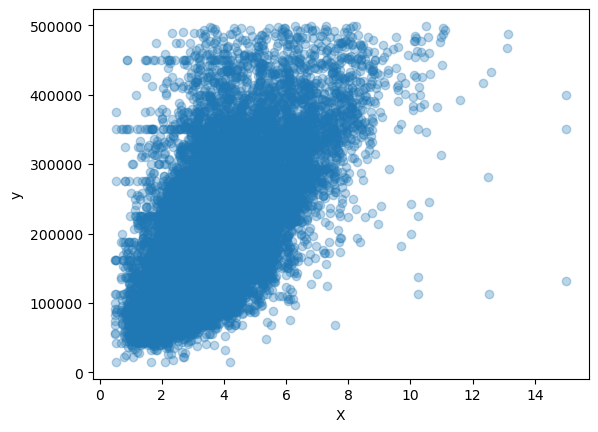

In [4]:
plt.scatter(X, y, alpha=0.3)
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [5]:
%run -i data_prepration/v2.py

/home/hananeh/Desktop/DeepLearningStepByStep/data_prepration/v2.py:4: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  X_tensor = torch.as_tensor(X).float()


In [6]:
X_tensor.shape, y_tensor.shape

(torch.Size([19648, 1]), torch.Size([19648, 1]))

## Model

In [7]:
# This returns model, loss function and optimizer
%run -i model_configuration/v4.py

In [8]:
model, loss_function, optimizer

(Sequential(
   (0): Linear(in_features=1, out_features=1, bias=True)
 ),
 MSELoss(),
 SGD (
 Parameter Group 0
     dampening: 0
     differentiable: False
     foreach: None
     fused: None
     lr: 0.01
     maximize: False
     momentum: 0
     nesterov: False
     weight_decay: 0
 ))

In [9]:
print(model.state_dict())

OrderedDict({'0.weight': tensor([[-0.0075]]), '0.bias': tensor([0.5364])})


## Training

In [13]:
sbs = StepByStep(model, loss_function, optimizer)
sbs.set_loaders(train_loader, val_loader)
sbs.set_tensorboard('classy')

In [15]:
print(sbs.model == model)
print(sbs.model)

True
Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
)


In [ ]:
sbs.train(n_epochs=100)

In [ ]:
sbs.save_checkpoint('model_checkpoint.pth')

In [17]:
print(model.state_dict()) # remember, model == sbs.model
print(sbs.total_epochs)

OrderedDict({'0.weight': tensor([[40925.2656]]), '0.bias': tensor([44251.5273])})
100


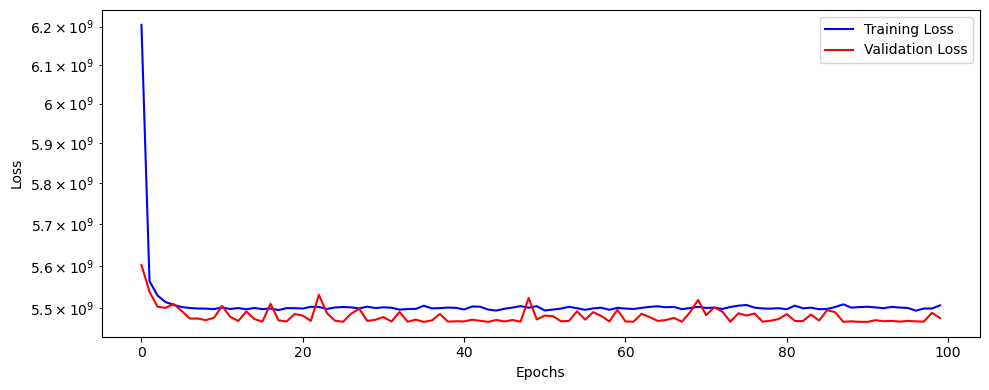

In [18]:
fig = sbs.plot_losses()

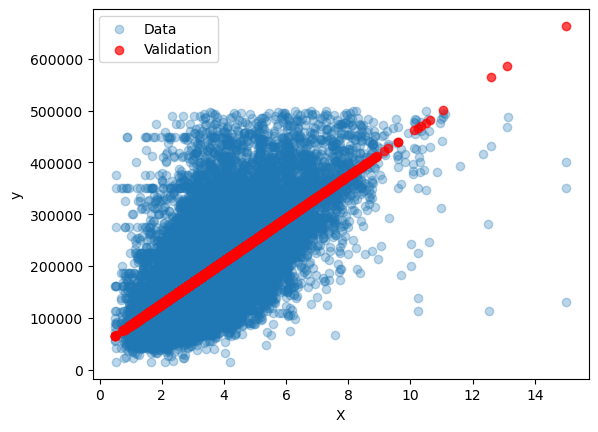

In [23]:
plt.scatter(X, y, alpha=0.3, label="Data")
plt.scatter(all_inputs, all_preds, alpha=0.7, color="red", label="Validation")

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

### Deploying / Making Predictions

In [19]:
new_data = np.array([.5, .3, .7]).reshape(-1, 1)

In [20]:
predictions = sbs.predict(new_data)
predictions

array([[64714.16],
       [56529.11],
       [72899.21]], dtype=float32)